In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import optuna
from pathlib import Path


c:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "mushrooms_clean.csv"
df = pd.read_csv(data_path)
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,unknown,w,16.95,17.09,w,t,g,d,w
1,p,16.60,x,g,o,f,e,unknown,w,17.99,18.19,w,t,g,d,u
2,p,14.07,x,g,o,f,e,unknown,w,17.80,17.74,w,t,g,d,w
3,p,14.17,f,h,e,f,e,unknown,w,15.77,15.98,w,t,p,d,w
4,p,14.64,x,h,o,f,e,unknown,w,16.53,17.20,w,t,p,d,w


In [3]:
X = df.drop('class', axis=1)
y = df['class']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

In [6]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier()
}

In [7]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

In [8]:
for name, pipe in pipelines.items():
    print(f"Entrenando {name}...")
    pipe.fit(X_train, y_train)

Entrenando LogReg...
Entrenando RandomForest...
Entrenando GradientBoosting...


In [9]:
cv_results = {}

for name, pipe in pipelines.items():

    print(f"Cross Validation: {name}")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

cv_results

Cross Validation: LogReg
Cross Validation: RandomForest
Cross Validation: GradientBoosting


{'LogReg': np.float64(0.7767363042380008),
 'RandomForest': np.float64(1.0),
 'GradientBoosting': np.float64(0.9359664327755319)}

In [10]:
predictions = {}

for name, pipe in pipelines.items():
    predictions[name] = pipe.predict(X_test)

In [ ]:
results = []

for name, pipe in pipelines.items():

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    results.append({
    "Modelo": name,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "CV F1": cv_results[name],
    "Overfitting": train_acc - test_acc
    })

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .round(4)
    .sort_values("Test Accuracy", ascending=False)
)

results_df

,Train Accuracy,Test Accuracy,Gap
LogReg,0.7816,0.7783,0.0033
RandomForest,1.0000,1.0000,0.0000
GradientBoosting,0.9298,0.9292,0.0006


In [13]:
print(classification_report(
    y_test,
    predictions["RandomForest"]
))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      5436
           p       1.00      1.00      1.00      6749

    accuracy                           1.00     12185
   macro avg       1.00      1.00      1.00     12185
weighted avg       1.00      1.00      1.00     12185



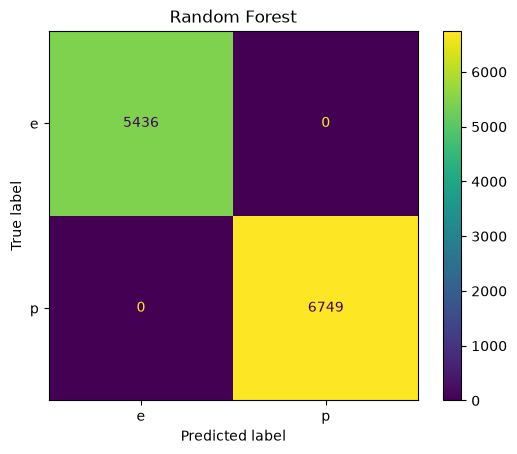

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions["RandomForest"]
)

plt.title("Random Forest")
plt.show()